#  EN3160 Assignment_1 on Intensity Transformations and Neighborhood Filtering.

In [1]:
# Task 1
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs, ys = breakpoints[:, 0], breakpoints[:, 1]

    lut = np.interp(np.arange(256), xs, ys).astype(np.uint8)
    out = cv.LUT(im, lut)
    return out, lut


In [7]:
def load_image(path, condition):
    match condition:
        case True:
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        case False:
            img = cv.imread(path)

    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    return img

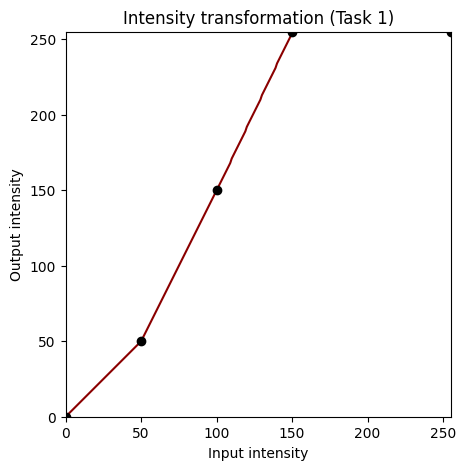

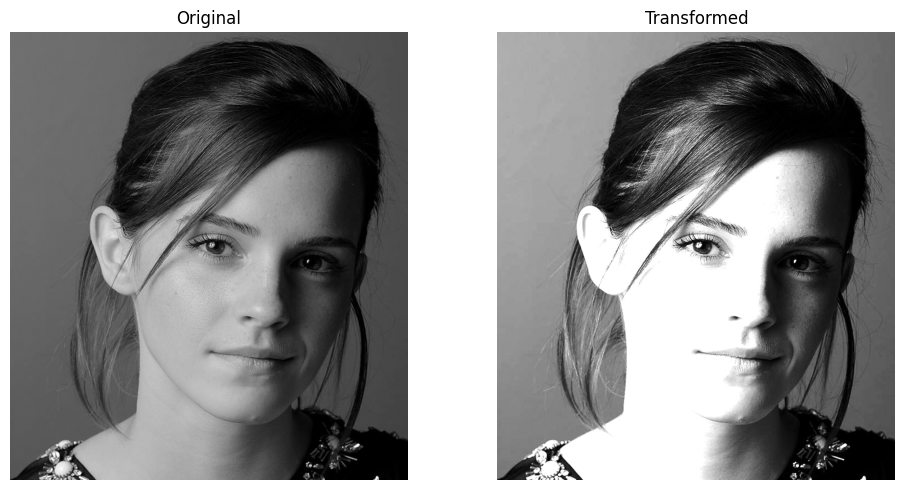

In [8]:
def task_01():
    img = load_image("images/q1.jpeg", True)

    breakpoints = np.array([
        [0,   0],
        [50,  50],
        [100, 150],
        [150, 255],
        [255, 255],
    ])

    out, lut = intensity_transform(img, breakpoints)

    # Plot the transformation curve
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(256), lut, color="darkred")
    ax.plot(breakpoints[:, 0], breakpoints[:, 1], "ko")
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_xlabel("Input intensity")
    ax.set_ylabel("Output intensity")
    ax.set_title("Intensity transformation (Task 1)")
    ax.set_aspect("equal")
    plt.savefig("task1_transform_plot.png", dpi=150)
    plt.show()

    # Original vs transformed image
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(out, cmap="gray")
    axes[1].set_title("Transformed")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task1_before_after.png", dpi=150)
    plt.show()

    cv.imwrite("task1_output.png", out)

task_01()

### Task 02

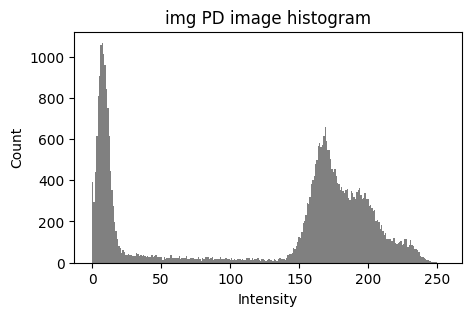

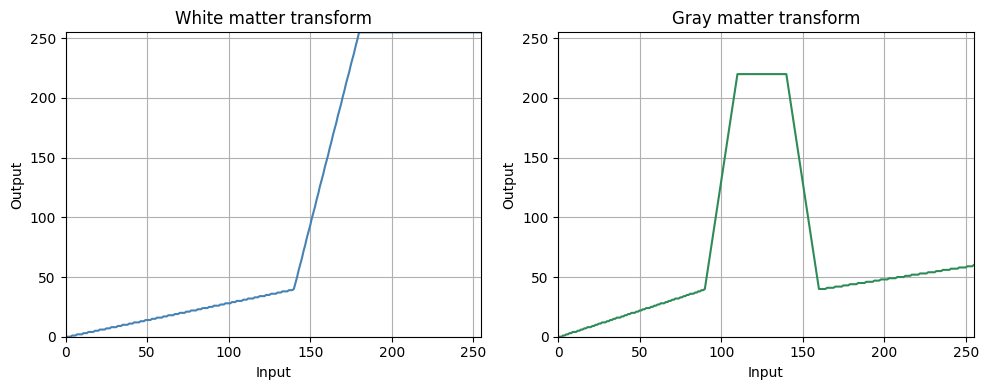

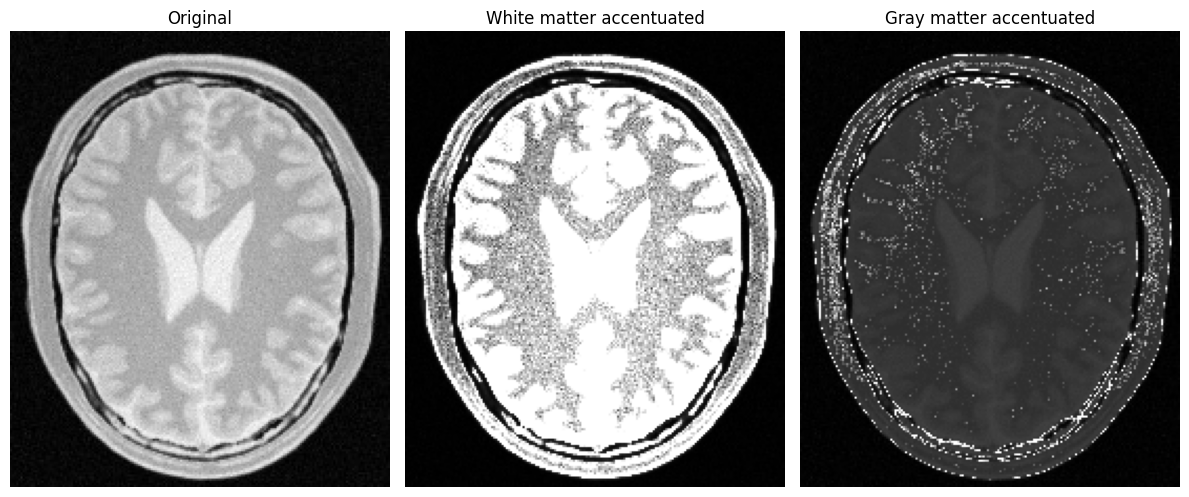

In [9]:
def task_02():
    img = load_image("images/q2.jpeg", True)
    # Inspect the histogram first to choose good breakpoints
    plt.figure(figsize=(5, 3))
    plt.hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    plt.title("img PD image histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.savefig("task2_histogram.png", dpi=150)
    plt.show()

    # White matter is typically the brightest tissue -> accentuate high intensities
    breakpoints_white = np.array([
        [0,   0],
        [140, 40],
        [180, 255],
        [200, 255],
        [255, 255],
    ])

    # Gray matter occupies a mid-intensity band -> accentuate a narrower mid band
    breakpoints_gray = np.array([
        [0,   0],
        [90,  40],
        [110, 220],
        [140, 220],
        [160, 40],
        [255, 60],
    ])

    white_img, white_lut = intensity_transform(img, breakpoints_white)
    gray_img, gray_lut = intensity_transform(img, breakpoints_gray)

    # Plot both transformation curves
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(white_lut, color="steelblue")
    axes[0].set_title("White matter transform")
    axes[1].plot(gray_lut, color="seagreen")
    axes[1].set_title("Gray matter transform")

    for ax in axes:
        ax.set_xlim(0, 255)
        ax.set_ylim(0, 255)
        ax.set_xlabel("Input")
        ax.set_ylabel("Output")
        ax.grid(True)
        
    plt.tight_layout()
    plt.savefig("task2_transform_curves.png", dpi=150)
    plt.show()

    # Show original, white-accentuated, gray-accentuated images
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for ax, im, title in zip(
        axes,
        [img, white_img, gray_img],
        ["Original", "White matter accentuated", "Gray matter accentuated"],
    ):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task2_results.png", dpi=150)
    plt.show()

    cv.imwrite("task2_white_matter.png", white_img)
    cv.imwrite("task2_gray_matter.png", gray_img)

task_02()

### Task 03


Gamma value used: 0.6


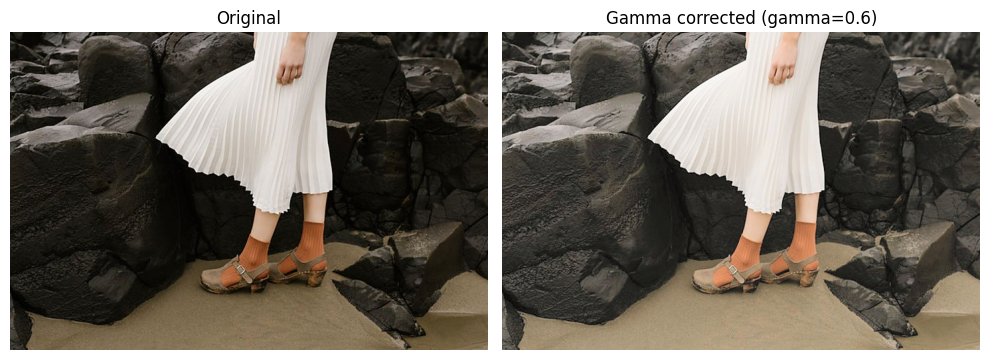

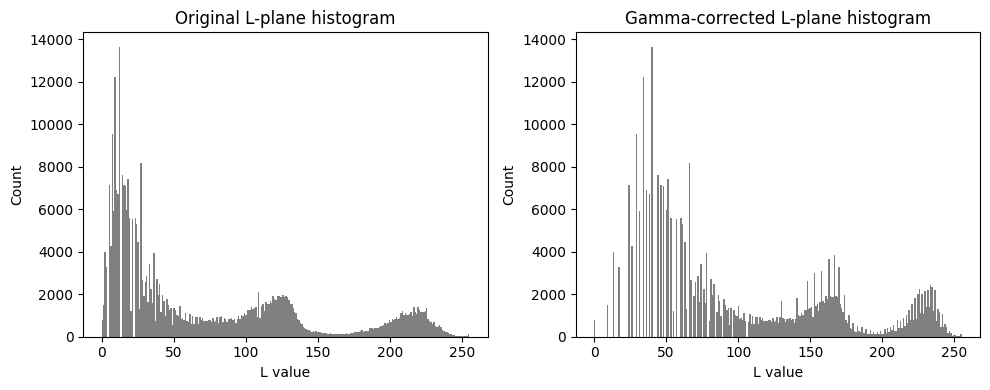

In [10]:
def task_03():
    img= load_image("images/q3.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)

    gamma = 0.6
    L_norm = L.astype(np.float64) / 255.0
    L_gamma = np.power(L_norm, gamma) * 255.0
    L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

    lab_corrected = cv.merge([L_gamma, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
    img_corrected_rgb = cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB)

    print(f"Gamma value used: {gamma}")

    # Original vs corrected
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_corrected_rgb)
    axes[1].set_title(f"Gamma corrected (gamma={gamma})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task3_before_after.png", dpi=150)
    plt.show()

    # Histograms of L plane before/after
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(L.ravel(), bins=256, range=(0, 255), color="gray")
    axes[0].set_title("Original L-plane histogram")
    axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1].set_title("Gamma-corrected L-plane histogram")
    for ax in axes:
        ax.set_xlabel("L value")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig("task3_histograms.png", dpi=150)
    plt.show()

    cv.imwrite("task3_output.png", img_corrected)


task_03()

a = 0.6, sigma = 70


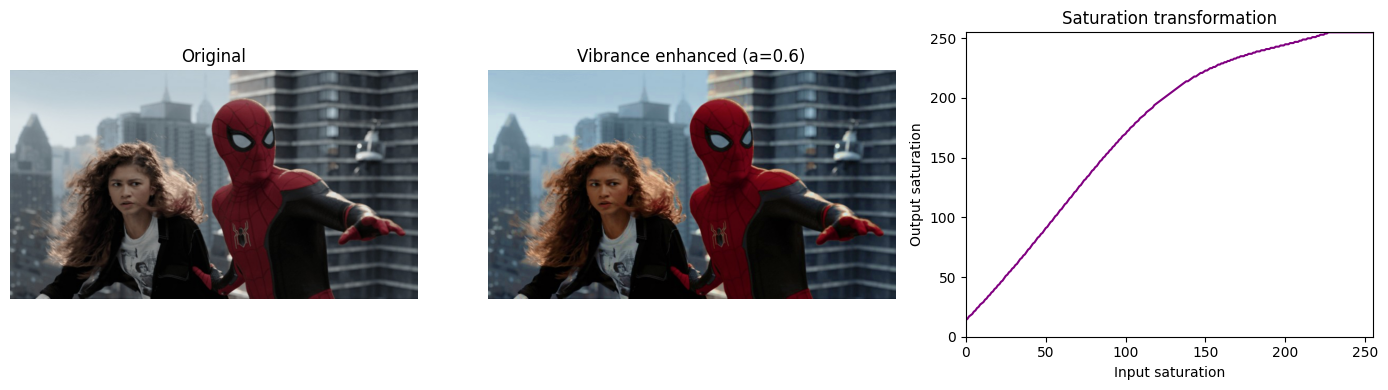

In [ ]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255).astype(np.uint8)


def task_04():
    img = load_image("images/q4.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Split into hue, saturation, value
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    # (b), (c) Apply the vibrance transform to the saturation plane
    a = 0.6  # in [0, 1]; tune for a visually pleasing result and report the value
    sigma = 70
    s_boosted = vibrance_transform(s, a, sigma)

    # (d) Recombine the three planes
    hsv_boosted = cv.merge([h, s_boosted, v])
    img_vibrant = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)
    img_vibrant_rgb = cv.cvtColor(img_vibrant, cv.COLOR_BGR2RGB)

    print(f"a = {a}, sigma = {sigma}")

    # (e) Display original, vibrance-enhanced, and the transformation curve
    xs = np.arange(256)
    ys = vibrance_transform(xs, a, sigma)

    fig, axes = plt.subplots(1, , figsize=(14, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_vibrant_rgb)
    axes[1].set_title(f"Vibrance enhanced (a={a})")
    axes[1].axis("off")
    axes[2].plot(xs, ys, color="purple")
    axes[2].set_title("Saturation transformation")
    axes[2].set_xlabel("Input saturation")
    axes[2].set_ylabel("Output saturation")
    axes[2].set_xlim(0, 255)
    axes[2].set_ylim(0, 255)
    plt.tight_layout()
    plt.savefig("task4_results.png", dpi=150)
    plt.show()

    cv.imwrite("task4_output.png", img_vibrant)


task_04()

### Task 05

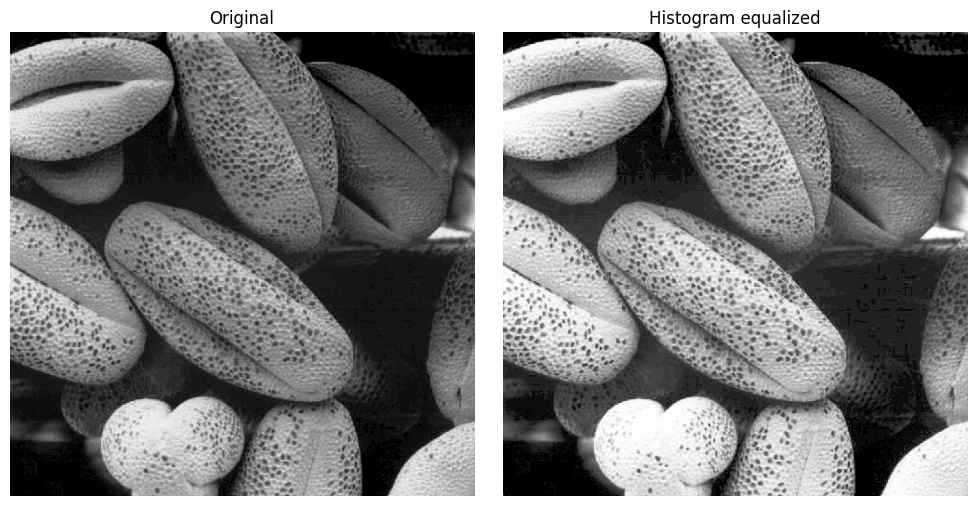

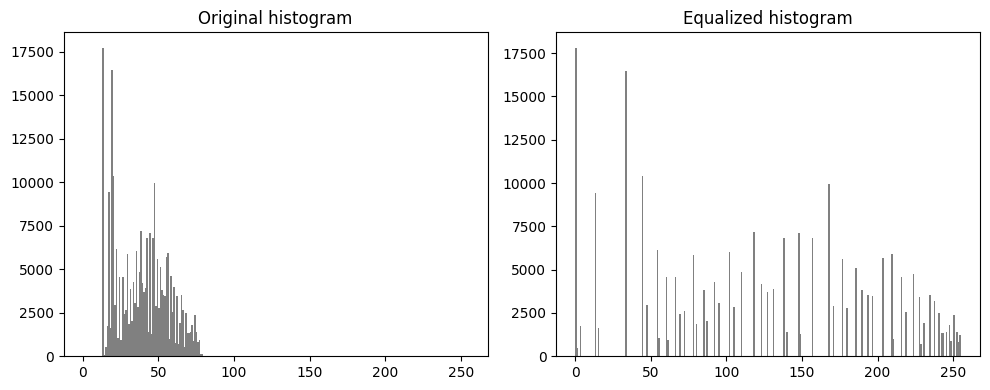

SSD between our equalization and cv.equalizeHist: 0.00


In [15]:
def histogram_equalize(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = np.cumsum(hist).astype(np.float64)
    cdf_min = cdf[cdf > 0].min()
    total_pixels = im.size

    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return cv.LUT(im, lut)



def task_05():
    img = load_image("images/q5.tif", True)

    img_eq = histogram_equalize(img)

    # Original vs equalized
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_eq, cmap="gray")
    axes[1].set_title("Histogram equalized")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task5_before_after.png", dpi=150)
    plt.show()

    # Histograms before/after
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    axes[0].set_title("Original histogram")
    axes[1].hist(img_eq.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1].set_title("Equalized histogram")
    plt.tight_layout()
    plt.savefig("task5_histograms.png", dpi=150)
    plt.show()

    # Sanity check against OpenCV's built-in implementation
    img_eq_cv = cv.equalizeHist(img)
    ssd = np.sum((img_eq.astype(np.float64) - img_eq_cv.astype(np.float64)) ** 2)
    print(f"SSD between our equalization and cv.equalizeHist: {ssd:.2f}")

    cv.imwrite("task5_output.png", img_eq)


task_05()

### Task 06

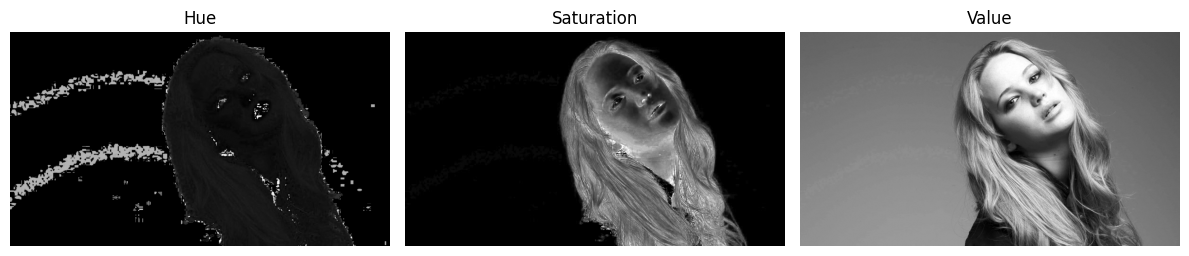

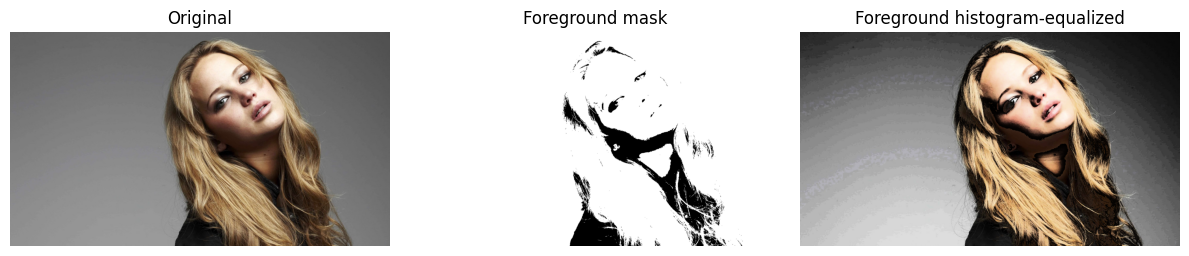

In [ ]:
def task_06():
    img_bgr = load_image("images/q6.jpeg", False)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # (a) Split into H, S, V and display each plane in grayscale
    hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, plane, title in zip(axes, [h, s, v], ["Hue", "Saturation", "Value"]):
        ax.imshow(plane, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task6_hsv_planes.png", dpi=150)
    plt.show()

    # (b) Threshold the plane that best separates subject from background.
    _, mask = cv.threshold(v, 60, 255, cv.THRESH_BINARY)
    mask = mask.astype(np.uint8)

    # (c) Foreground only and its histogram (computed over masked pixels only)
    foreground = cv.bitwise_and(v, v, mask=mask)
    hist_fg = cv.calcHist([v], [0], mask, [256], [0, 256]).flatten()

    # (d) Cumulative sum of the foreground histogram
    cdf_fg = np.cumsum(hist_fg)

    # (e) Histogram-equalize the foreground using the standard CDF formula-----------------------------------------
    cdf_min = cdf_fg[cdf_fg > 0].min()
    n_fg_pixels = cdf_fg[-1]
    lut_fg = np.round((cdf_fg - cdf_min) / (n_fg_pixels - cdf_min) * 255.0)
    lut_fg = np.clip(lut_fg, 0, 255).astype(np.uint8)

    fg_equalized = cv.LUT(v, lut_fg)
    fg_equalized = cv.bitwise_and(fg_equalized, fg_equalized, mask=mask)

    # (f) Extract the background and add it to the equalized foreground
    inv_mask = cv.bitwise_not(mask)
    background = cv.bitwise_and(v, v, mask=inv_mask)
    v_result = cv.add(background, fg_equalized)

    hsv_result = cv.merge([h, s, v_result])
    img_result = cv.cvtColor(hsv_result, cv.COLOR_HSV2BGR)
    img_result_rgb = cv.cvtColor(img_result, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for ax, im, title in zip(
        axes,
        [img_rgb, mask, img_result_rgb],
        ["Original", "Foreground mask", "Foreground histogram-equalized"],
    ):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task6_results.png", dpi=150)
    plt.show()

    cv.imwrite("task6_mask.png", mask)
    cv.imwrite("task6_output.png", img_result)


task_06()

### Task 07

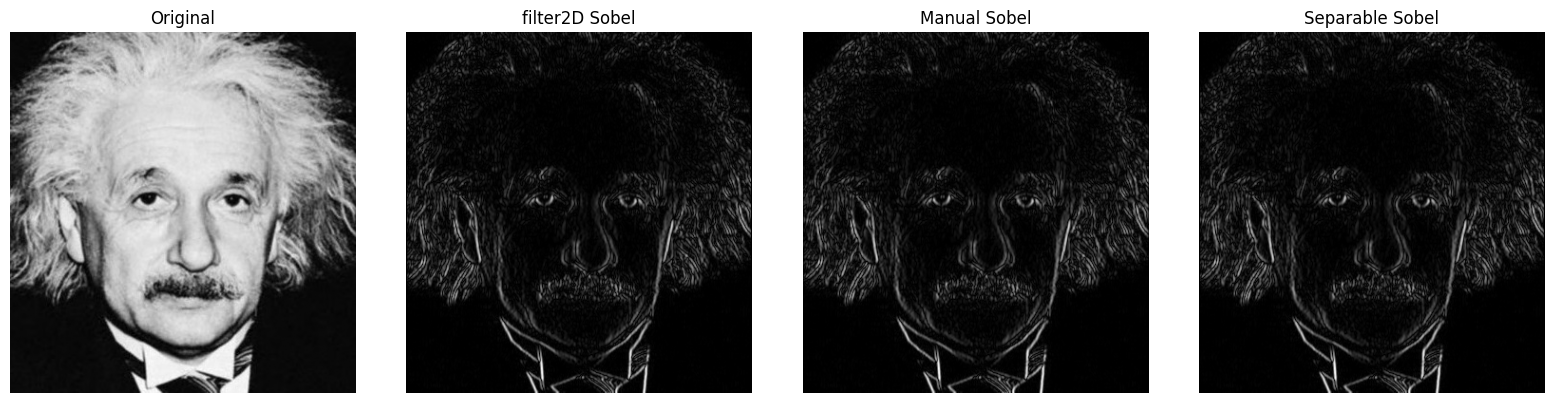

SSD between filter2D and separable implementation: 0.0000


In [17]:
def sobel_manual(im, kernel):
    im = im.astype(np.float64)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(im)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i + im.shape[0], j:j + im.shape[1]]
    return out


def to_display(im):
    im = np.abs(im)
    return (255 * im / (im.max() + 1e-8)).astype(np.uint8)


def task_07():
    img_grayed = load_image("images/q7.jpeg", True)

    # (a) Using cv.filter2D with the standard 3x3 Sobel kernel
    sobel_x_kernel = np.array([[1, 0, -1],
                                [2, 0, -2],
                                [1, 0, -1]], dtype=np.float64)

    sobel_x_cv = cv.filter2D(img_grayed.astype(np.float64), -1, sobel_x_kernel)

    # (b) Own manual implementation
    sobel_x_manual = sobel_manual(img_grayed, sobel_x_kernel)

    # (c) Separable implementation: [1,0,-1] with column [1,2,1]^T
    col = np.array([[1], [2], [1]], dtype=np.float64)
    row = np.array([[1, 0, -1]], dtype=np.float64)

    tmp = cv.filter2D(img_grayed.astype(np.float64), -1, col)   # vertical smoothing pass
    sobel_x_separable = cv.filter2D(tmp, -1, row)               # horizontal derivative pass

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    imgs = [img_grayed, to_display(sobel_x_cv), to_display(sobel_x_manual), to_display(sobel_x_separable)]
    titles = ["Original", "filter2D Sobel", "Manual Sobel", "Separable Sobel"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task7_results.png", dpi=150)
    plt.show()

    diff = np.sum((sobel_x_cv - sobel_x_separable) ** 2)
    print(f"SSD between filter2D and separable implementation: {diff:.4f}")

    cv.imwrite("task7_sobel_cv.png", to_display(sobel_x_cv))
    cv.imwrite("task7_sobel_manual.png", to_display(sobel_x_manual))
    cv.imwrite("task7_sobel_separable.png", to_display(sobel_x_separable))


task_07()

### Task 08

images/im01small.png: nearest-neighbor SSD = 136.269, bilinear SSD = 115.126


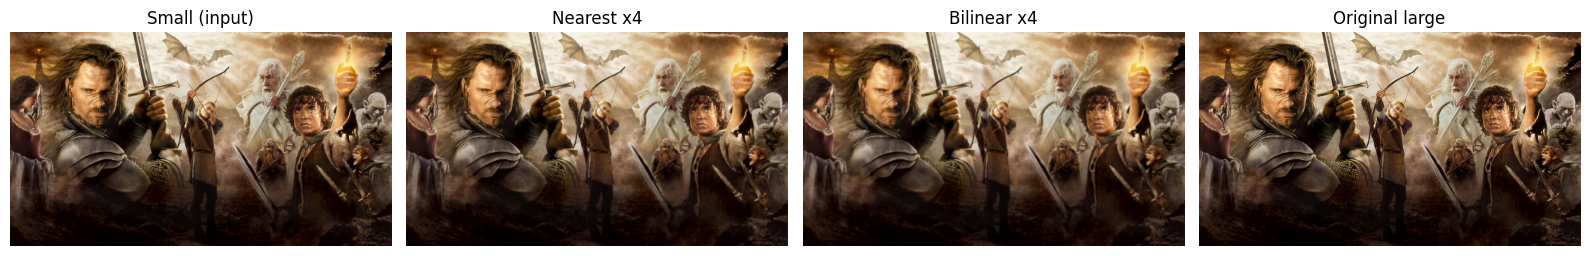

images/im02small.png: nearest-neighbor SSD = 26.446, bilinear SSD = 18.397


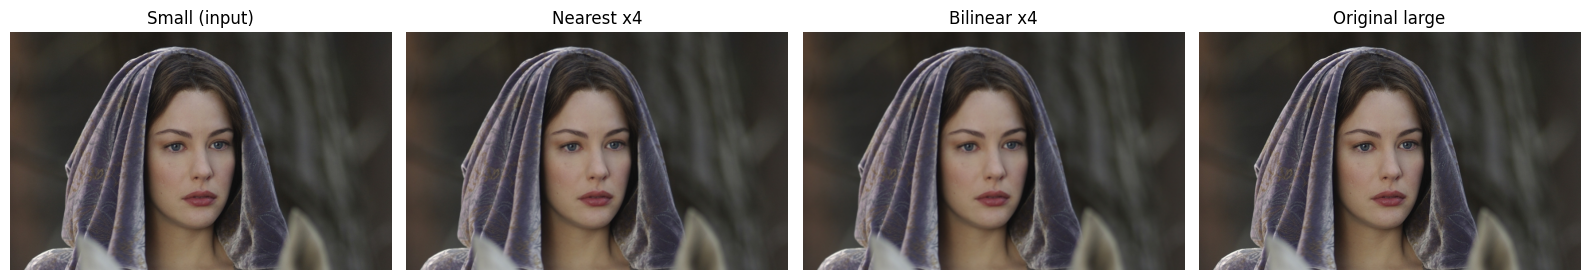

images/im03small.png: nearest-neighbor SSD = 67.582, bilinear SSD = 51.320


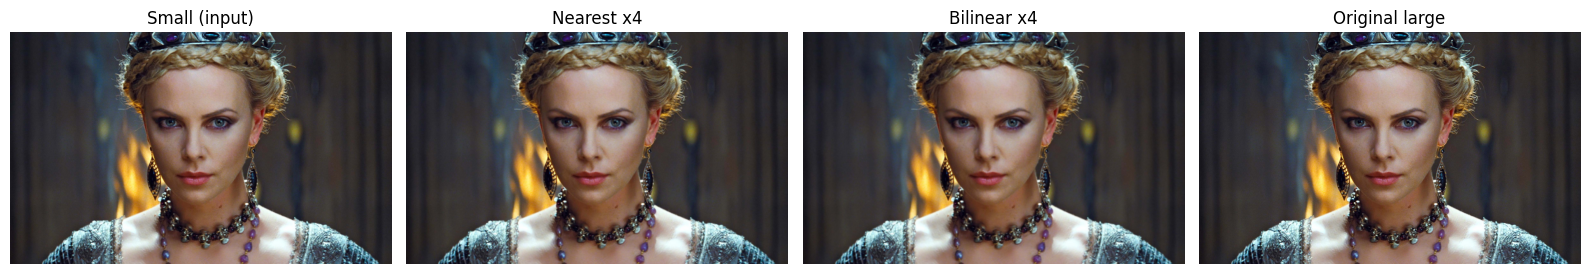

images/im04small.jpg: nearest-neighbor SSD = 228.622, bilinear SSD = 196.766


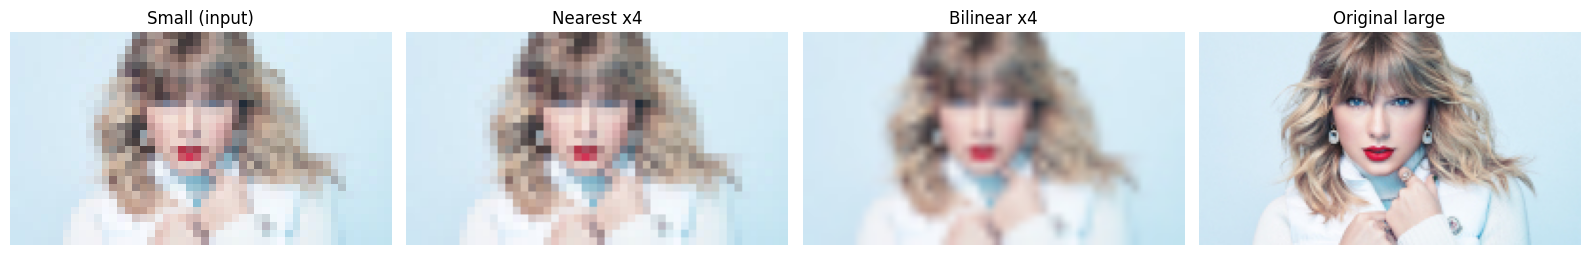

In [19]:
def zoom_image(im, s, method="bilinear"):
    """
    im     : input image (H, W) or (H, W, C), any dtype
    s      : zoom factor in (0, 10]
    method : 'nearest' or 'bilinear'
    """
    assert 0 < s <= 10, "s must be in (0, 10]"
    im_f = im.astype(np.float64)
    H, W = im.shape[:2]
    new_H, new_W = max(1, round(H * s)), max(1, round(W * s))

    # Coordinates in the *source* image corresponding to each output pixel
    ys = (np.arange(new_H) + 0.5) / s - 0.5
    xs = (np.arange(new_W) + 0.5) / s - 0.5

    if method == "nearest":
        y_idx = np.clip(np.round(ys), 0, H - 1).astype(int)
        x_idx = np.clip(np.round(xs), 0, W - 1).astype(int)
        out = im_f[np.ix_(y_idx, x_idx)]

    elif method == "bilinear":
        y0 = np.clip(np.floor(ys), 0, H - 1).astype(int)
        x0 = np.clip(np.floor(xs), 0, W - 1).astype(int)
        y1 = np.clip(y0 + 1, 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1)

        wy = np.clip(ys - y0, 0, 1)
        wx = np.clip(xs - x0, 0, 1)

        Ia = im_f[np.ix_(y0, x0)]
        Ib = im_f[np.ix_(y0, x1)]
        Ic = im_f[np.ix_(y1, x0)]
        Id = im_f[np.ix_(y1, x1)]

        wy_ = wy[:, None]
        wx_ = wx[None, :]
        if im_f.ndim == 3:
            wy_ = wy_[..., None]
            wx_ = wx_[..., None]

        top = Ia * (1 - wx_) + Ib * wx_
        bottom = Ic * (1 - wx_) + Id * wx_
        out = top * (1 - wy_) + bottom * wy_
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    return np.clip(out, 0, 255).astype(im.dtype)


def normalized_ssd(im1, im2):
    a = im1.astype(np.float64)
    b = im2.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size


def task_08():
    pairs = [
        ("images/im01small.png", "images/im01.png"),
        ("images/im02small.png", "images/im02.png"),
        ("images/im03small.png", "images/im03.png"),
        ("images/im04small.jpg", "images/im04.jpg"),
    ]

    for small_path, large_path in pairs:
        small_bgr = cv.imread(small_path)
        large_bgr = cv.imread(large_path)
        if small_bgr is None or large_bgr is None:
            print(f"Skipping missing pair: {small_path}, {large_path}")
            continue

        small = cv.cvtColor(small_bgr, cv.COLOR_BGR2RGB)
        large = cv.cvtColor(large_bgr, cv.COLOR_BGR2RGB)

        up_nn = zoom_image(small, 4, method="nearest")
        up_bl = zoom_image(small, 4, method="bilinear")

        # Crop to the same shape in case of rounding differences
        h = min(up_nn.shape[0], large.shape[0])
        w = min(up_nn.shape[1], large.shape[1])

        ssd_nn = normalized_ssd(up_nn[:h, :w], large[:h, :w])
        ssd_bl = normalized_ssd(up_bl[:h, :w], large[:h, :w])

        print(f"{small_path}: nearest-neighbor SSD = {ssd_nn:.3f}, bilinear SSD = {ssd_bl:.3f}")

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        imgs = [small, up_nn[:h, :w], up_bl[:h, :w], large[:h, :w]]
        titles = ["Small (input)", "Nearest x4", "Bilinear x4", "Original large"]
        for ax, im, title in zip(axes, imgs, titles):
            ax.imshow(im)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        out_name = f"task8_{small_path.split('/')[-1].split('.')[0]}_results.png"
        plt.savefig(out_name, dpi=150)
        plt.show()

task_08()

### Task 09

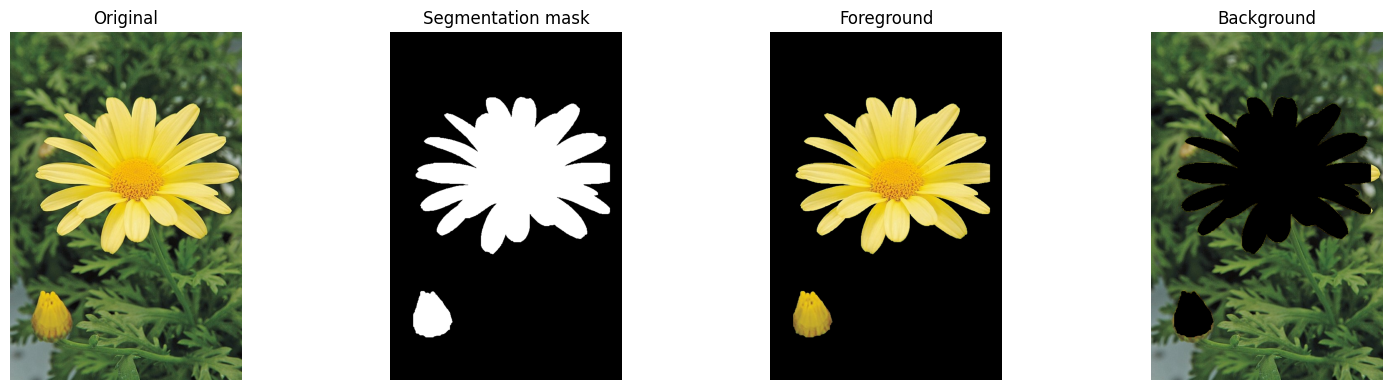

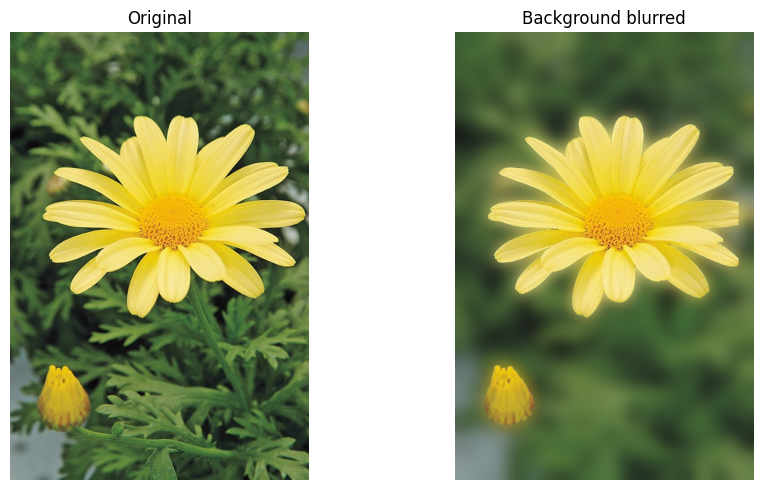

In [21]:
def task_09():
    flower_bgr = load_image("images/q9.jpeg", False)
    flower_rgb = cv.cvtColor(flower_bgr, cv.COLOR_BGR2RGB)

    # (a) GrabCut segmentation
    mask = np.zeros(flower_bgr.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    # Initial rectangle should tightly bound the flower; adjust to your image
    h, w = flower_bgr.shape[:2]
    rect = (int(0.1 * w), int(0.05 * h), int(0.85 * w), int(0.9 * h))

    cv.grabCut(flower_bgr, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

    final_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 255, 0).astype(np.uint8)

    foreground = cv.bitwise_and(flower_bgr, flower_bgr, mask=final_mask)
    background = cv.bitwise_and(flower_bgr, flower_bgr, mask=cv.bitwise_not(final_mask))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    imgs = [flower_rgb, final_mask, cv.cvtColor(foreground, cv.COLOR_BGR2RGB), cv.cvtColor(background, cv.COLOR_BGR2RGB)]
    titles = ["Original", "Segmentation mask", "Foreground", "Background"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task9_segmentation.png", dpi=150)
    plt.show()

    # (b) Substantially blur the background and recombine with the sharp foreground
    blurred_bg = cv.GaussianBlur(flower_bgr, (0, 0), sigmaX=15)

    mask_float = (final_mask.astype(np.float64) / 255.0)[..., None]
    enhanced = (flower_bgr.astype(np.float64) * mask_float +
                blurred_bg.astype(np.float64) * (1 - mask_float)).astype(np.uint8)
    enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(flower_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(enhanced_rgb)
    axes[1].set_title("Background blurred")
    axes[1].axis("off")
    plt.tight_layout()
    plt.savefig("task9_background_blur.png", dpi=150)
    plt.show()


    cv.imwrite("task9_mask.png", final_mask)
    cv.imwrite("task9_output.png", enhanced)

task_09()

### Task 10

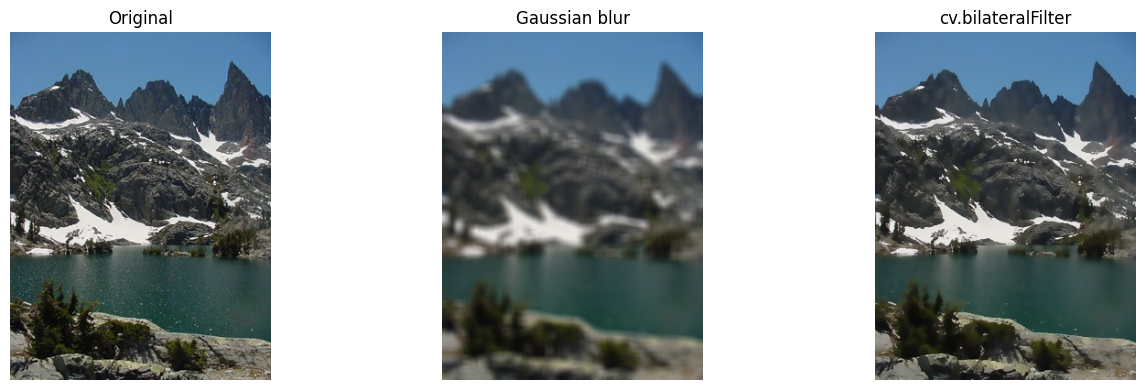

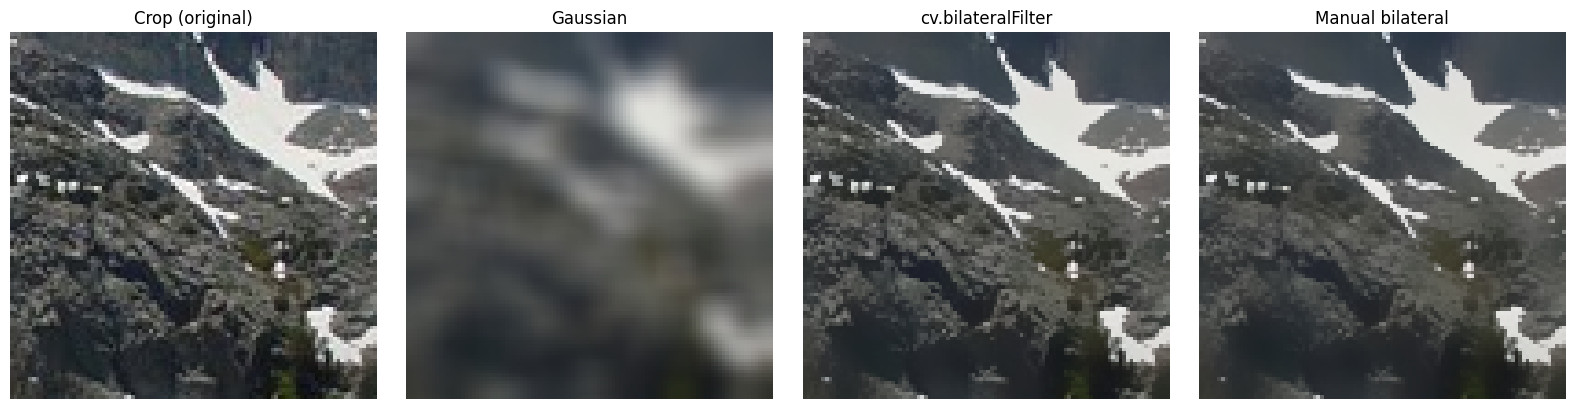

PSNR (manual vs cv.bilateralFilter): 33.51 dB
SSD  (manual vs cv.bilateralFilter): 869961.00


In [22]:
def bilateral_filter_manual(im, sigma_s, sigma_r, radius=None):
    if radius is None:
        radius = int(2 * sigma_s)

    im_f = im.astype(np.float64)
    H, W, C = im_f.shape
    padded = cv.copyMakeBorder(im_f, radius, radius, radius, radius, cv.BORDER_REFLECT)

    # Precompute the spatial Gaussian weights (same for every pixel)
    ax = np.arange(-radius, radius + 1)
    gx, gy = np.meshgrid(ax, ax)
    spatial_weights = np.exp(-(gx ** 2 + gy ** 2) / (2 * sigma_s ** 2))

    out = np.zeros_like(im_f)

    for i in range(H):
        for j in range(W):
            patch = padded[i:i + 2 * radius + 1, j:j + 2 * radius + 1, :]
            center = padded[i + radius, j + radius, :]
            diff = patch - center
            range_weights = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_r ** 2))
            weights = spatial_weights * range_weights
            weights_sum = weights.sum()
            out[i, j, :] = (patch * weights[..., None]).sum(axis=(0, 1)) / weights_sum

    return np.clip(out, 0, 255).astype(np.uint8)


def psnr(im1, im2):
    mse = np.mean((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))


def task_10():
    img_bgr = load_image("images/q10.jpeg", False)
    lake_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    sigma_s, sigma_r = 15, 75  # spatial / range sigmas, tune for visible edge-preserving smoothing

    # (a) OpenCV bilateral filter vs. Gaussian blur with a comparable kernel
    bilateral_cv = cv.bilateralFilter(img_bgr, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
    gaussian_cv = cv.GaussianBlur(img_bgr, (9, 9), sigmaX=sigma_s)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    imgs = [lake_rgb, cv.cvtColor(gaussian_cv, cv.COLOR_BGR2RGB), cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)]
    titles = ["Original", "Gaussian blur", "cv.bilateralFilter"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task10_opencv_bilateral.png", dpi=150)
    plt.show()

    # (b) Own implementation, compared on a small crop for reasonable runtime
    crop = img_bgr[100:200, 150:250]
    crop_bilateral_manual = bilateral_filter_manual(crop, sigma_s=5, sigma_r=50, radius=5)
    crop_bilateral_cv = cv.bilateralFilter(crop, d=11, sigmaColor=50, sigmaSpace=5)
    crop_gaussian = cv.GaussianBlur(crop, (11, 11), sigmaX=5)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    imgs = [
        cv.cvtColor(crop, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_gaussian, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_bilateral_cv, cv.COLOR_BGR2RGB),
        cv.cvtColor(crop_bilateral_manual, cv.COLOR_BGR2RGB),
    ]
    titles = ["Crop (original)", "Gaussian", "cv.bilateralFilter", "Manual bilateral"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task10_manual_vs_cv.png", dpi=150)
    plt.show()

    print(f"PSNR (manual vs cv.bilateralFilter): {psnr(crop_bilateral_manual, crop_bilateral_cv):.2f} dB")
    ssd = np.sum((crop_bilateral_manual.astype(np.float64) - crop_bilateral_cv.astype(np.float64)) ** 2)
    print(f"SSD  (manual vs cv.bilateralFilter): {ssd:.2f}")

    cv.imwrite("task10_bilateral_cv.png", bilateral_cv)

task_10()